In [1]:
# Import important libraries
import os
import re
import json
import string
import random
import pandas as pd
import numpy as np
import dask.dataframe as dd
import dask.bag as db
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from dask.distributed import Client

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.utils import shuffle
from sklearn.manifold import TSNE
from sklearn.preprocessing import Normalizer, StandardScaler, OneHotEncoder

# Visualization libraries
from IPython.display import display
import dask

In [2]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/amritap1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/amritap1/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amritap1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/amritap1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/amritap1/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/amritap1/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
from dask_jobqueue import SLURMCluster

# Compose SLURM script
cluster = SLURMCluster(queue='caslake', cores=10, memory='40GB', 
                       processes=10, walltime='03:00:00', interface='ib0',
                       job_extra=['--account=macs30123']
                      )

# Request resources
cluster.scale(jobs=1)

In [4]:
#! scancel 31340687

In [7]:
! squeue -u amritap1

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          31370314   caslake dask-wor amritap1  R       0:02      1 midway3-0047


In [8]:
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.25.0.66:8787/status,
Dashboard: http://172.25.0.66:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.25.0.66:35939,Workers: 0
Dashboard: http://172.25.0.66:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [9]:
### PREPROCESSING ### 

### LOAD AND MERGE REDDIT POSTS AND COMMENTS ###

# Set paths for data
posts_path = r"/home/amritap1/30123/final/submissions"
comments_path = r"/home/amritap1/30123/final/comments"

# List of all post and comment JSON files
json_files_posts = [f"RS_{str(year)}-{str(month).zfill(2)}_subreddit.json" for year in range(2014, 2019) for month in range(1, 13)]
json_files_comments = [f"RC_{str(year)}-{str(month).zfill(2)}_subreddit.json" for year in range(2014, 2019) for month in range(1, 13)]

In [10]:
def load_json_data_dask(folder_path, file_list, columns_to_keep, text_column, meta):
    """
    Loads JSON files into a Dask DataFrame, filters out deleted/removed content, and removes bot accounts.
    """
    # Use Dask Bag to read JSON lines in parallel
    bags = [db.read_text(os.path.join(folder_path, file)).map(json.loads) for file in file_list]
    bag = db.concat(bags)
    df = bag.to_dataframe(meta=meta)

    # Ensure necessary columns exist before filtering
    missing_cols = [col for col in columns_to_keep if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns: {missing_cols}")
    df = df[columns_to_keep]

    # Convert timestamps to datetime format
    df['created_utc'] = dd.to_datetime(df['created_utc'], unit='s', errors='coerce')

    # Remove deleted/empty content
    if text_column in df.columns:
        df = df[df[text_column].notnull() & ~df[text_column].isin(['[deleted]', '[removed]'])]

    # Remove bot accounts
    bot_keywords = ["AutoModerator", "Moderator", "bot", "AutoMod"]
    if "author" in df.columns:
        pattern = '|'.join(bot_keywords)
        df = df[~df["author"].str.contains(pattern, case=False, na=False)]

    return df

In [11]:
# Load posts and comments
columns_posts = ['title', 'selftext', 'score', 'num_comments', 'created_utc', 'author']
columns_comments = ['body', 'score', 'created_utc', 'author']
meta = {
    'title': 'object',
    'selftext': 'object',
    'score': 'Int64',
    'num_comments': 'Int64',
    'created_utc': 'object',
    'author': 'object',
}
df_posts = load_json_data_dask(posts_path, json_files_posts, columns_posts, 'selftext', meta)
meta = {
    'body': 'object',
    'score': 'Int64',
    'created_utc': 'object',
    'author': 'object',
}
df_comments = load_json_data_dask(comments_path, json_files_comments, columns_comments, 'body', meta)
     
# Merge title and selftext into one field for posts
df_posts['full_text'] = df_posts['title'].fillna('') + ' ' + df_posts['selftext'].fillna('')
df_posts = df_posts.drop(['title', 'selftext'], axis=1)
df_comments = df_comments.rename(columns={'body': 'full_text'})

df_posts['source'] = 'post'
df_comments['source'] = 'comment'

df = dd.concat([df_posts, df_comments], axis=0, interleave_partitions=True)

In [12]:
df.dtypes

score                    Int64
num_comments             Int64
created_utc     datetime64[ns]
author                  object
full_text               object
source                  object
dtype: object

In [13]:
df.head()

,score,num_comments,created_utc,author,full_text,source
0,3,13,2014-01-01 01:09:19,leatherheadff,For all of you that keep asking how to invest ...,post
1,1,2,2014-01-01 03:48:45,[deleted],KNDI $5.00 put options? Kandi Technologies Gro...,post
2,23,55,2014-01-01 04:14:53,americanpegasus,"I want to issue a public ""$10k Challenge"" for ...",post
3,4,19,2014-01-01 04:15:14,xDerivative,I've been talking with AmericanPegasus - here'...,post
4,8,11,2014-01-01 06:02:45,americanpegasus,[Off-Topic] New Years Eve and New Years Day Pa...,post


In [14]:
### TEXT CLEANING FUNCTION ###
def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and word not in ["nan", "ill", "im", "i'm"]]
    lemmatizer = WordNetLemmatizer()
    def get_pos_tag(word):
        tag = pos_tag([word])[0][1]
        if tag.startswith('N'):
            return 'n'
        elif tag.startswith('V'):
            return 'v'
        elif tag.startswith('J'):
            return 'a'
        elif tag.startswith('R'):
            return 'r'
        else:
            return 'n'
    tokens = [lemmatizer.lemmatize(word, get_pos_tag(word)) for word in tokens]
    return " ".join(tokens)

In [15]:
# Apply cleaning to full_text using Dask map_partitions
df['cleaned_text'] = df['full_text'].map_partitions(lambda part: part.apply(clean_text), meta=('cleaned_text', 'object'))
df = df.drop('full_text', axis=1)

In [16]:
# Function to remove specific words from cleaned text
def remove_custom_words_dask(text, words_to_remove):
    if not isinstance(text, str):
        return text
    words_pattern = r'\\b(' + '|'.join(re.escape(word) for word in words_to_remove) + r')\\b'
    text = re.sub(words_pattern, '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

custom_words = ["thanks", "like", "go"]
df['cleaned_text'] = df['cleaned_text'].map_partitions(lambda part: part.apply(remove_custom_words_dask, args=(custom_words,)), meta=('cleaned_text', 'object'))

In [17]:
df.head()

,score,num_comments,created_utc,author,source,cleaned_text
0,3,13,2014-01-01 01:09:19,leatherheadff,post,keep ask invest weed mdbx might option first r...
1,1,2,2014-01-01 03:48:45,[deleted],post,kndi put option kandi technology group way pas...
2,23,55,2014-01-01 04:14:53,americanpegasus,post,want issue public k challenge year think beat ...
3,4,19,2014-01-01 04:15:14,xDerivative,post,ive talk americanpegasus here challenge mod kn...
4,8,11,2014-01-01 06:02:45,americanpegasus,post,offtopic new year eve new year day party wsb b...


In [18]:
df.persist()

,score,num_comments,created_utc,author,source,cleaned_text
npartitions=120,,,,,,
,Int64,Int64,datetime64[ns],object,object,object
,...,...,...,...,...,...
...,...,...,...,...,...,...
,...,...,...,...,...,...
,...,...,...,...,...,...


In [17]:
texts_bag = df['cleaned_text'].dropna().to_bag()
words_bag = texts_bag.map(lambda text: re.findall(r'\b\w+\b', text.lower())).flatten()
top_words = words_bag.frequencies().topk(20, key=lambda x: x[1]).compute()
print("Top 20 Most Common Words:", top_words)

Top 20 Most Common Words: [('go', 377143), ('get', 365902), ('like', 277419), ('call', 248926), ('make', 233757), ('fuck', 215969), ('sell', 214807), ('put', 193098), ('think', 190500), ('buy', 186684), ('stock', 177835), ('dont', 177201), ('money', 174561), ('market', 167260), ('would', 158302), ('time', 154777), ('day', 153083), ('good', 151640), ('one', 150275), ('well', 145912)]


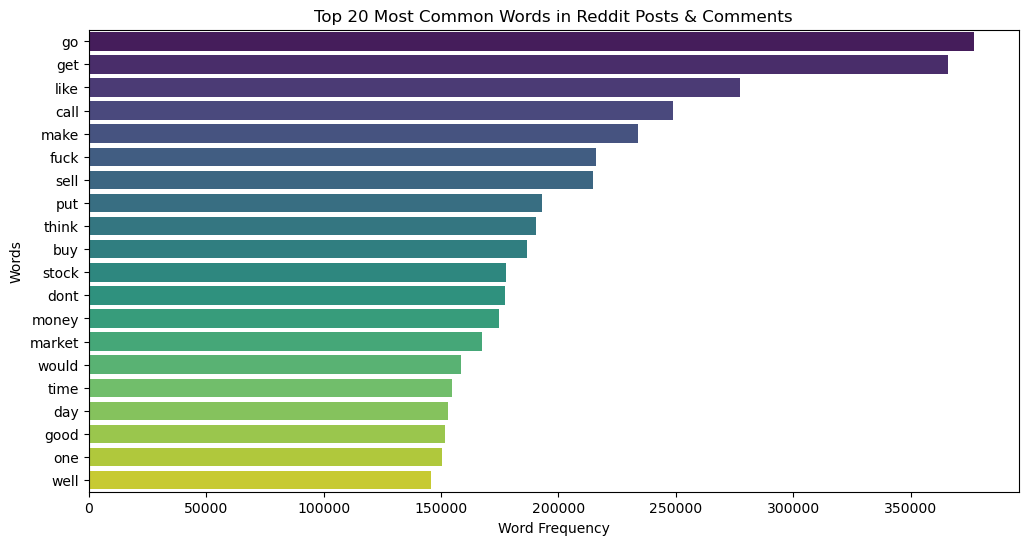

In [20]:
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis')
plt.xlabel('Word Frequency')
plt.ylabel('Words')
plt.title('Top 20 Most Common Words in Reddit Posts & Comments')
plt.show()

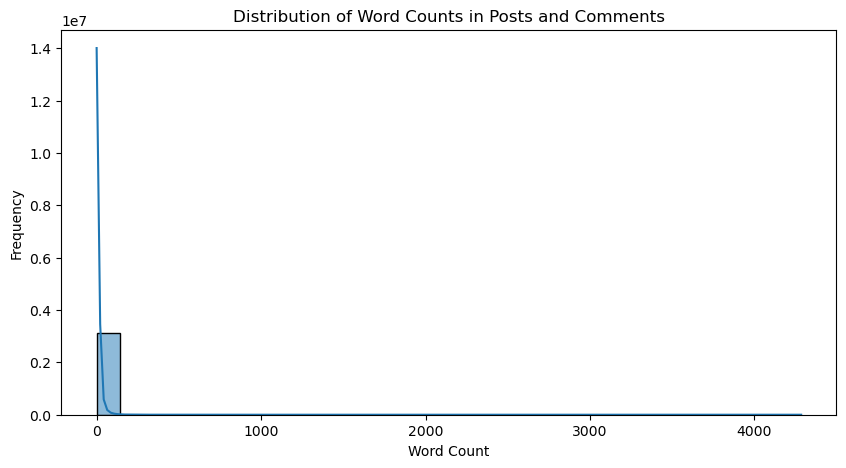

In [21]:
word_count_series = df['cleaned_text'] \
    .map(lambda text: len(str(text).split()) if isinstance(text, str) else 0) \
    .compute()
plt.figure(figsize=(10, 5))
sns.histplot(word_count_series, bins=30, kde=True)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts in Posts and Comments')
plt.show()

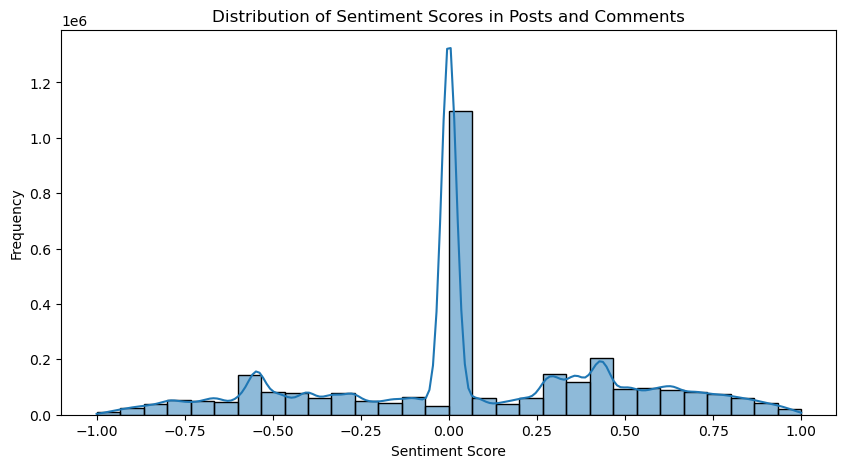

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sentiment_scores = df['cleaned_text'] \
    .map(lambda text: sia.polarity_scores(text)['compound']) \
    .compute()
plt.figure(figsize=(10, 5))
sns.histplot(sentiment_scores, bins=30, kde=True)
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Scores in Posts and Comments')
plt.show()

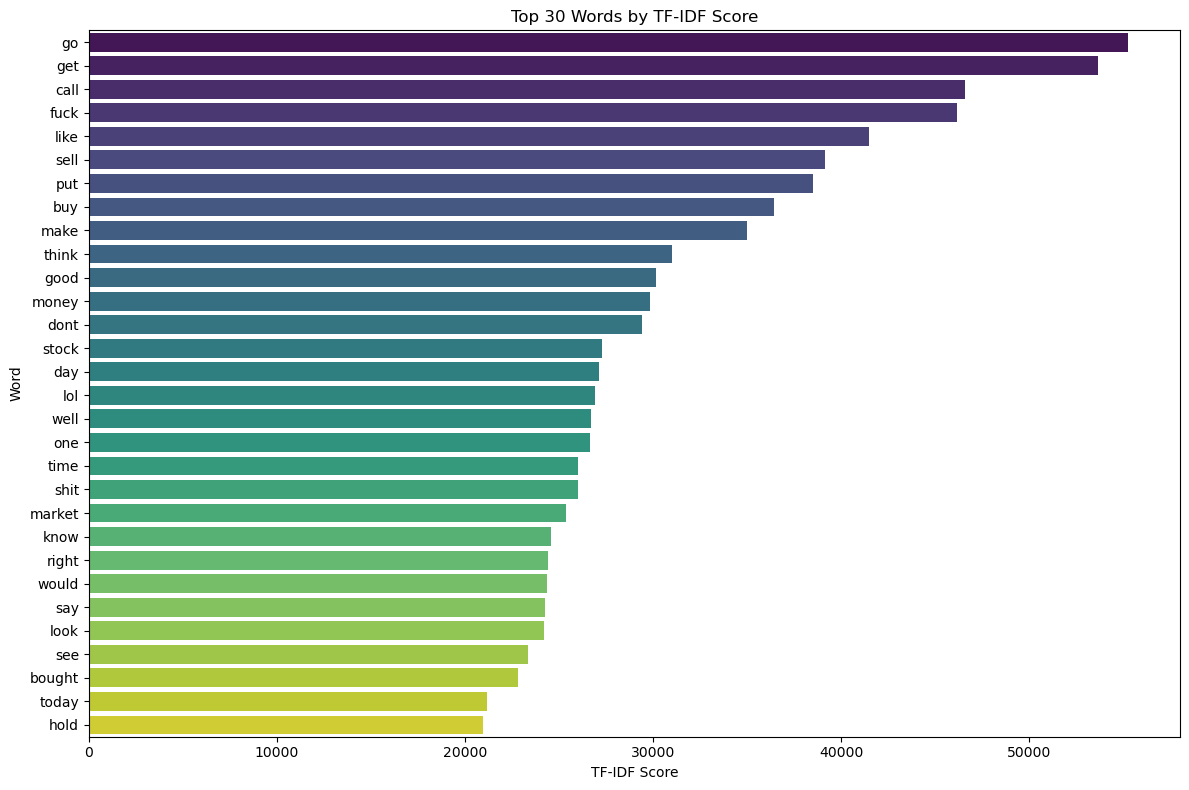

In [19]:
# Compute TF-IDF scores and plot top 30 words
from sklearn.feature_extraction.text import TfidfVectorizer

# Retrieve cleaned text as list
texts = df['cleaned_text'].dropna().compute().tolist()

# Fit TF-IDF vectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

# Aggregate scores and prepare DataFrame
scores = tfidf_matrix.sum(axis=0).A1
tfidf_scores_df = pd.DataFrame({'word': feature_names, 'score': scores})

# Select top 30 and plot
top30 = tfidf_scores_df.sort_values(by='score', ascending=False).head(30)
plt.figure(figsize=(12, 8))
sns.barplot(x='score', y='word', data=top30, palette='viridis')
plt.xlabel('TF-IDF Score')
plt.ylabel('Word')
plt.title('Top 30 Words by TF-IDF Score')
plt.tight_layout()
plt.show()

In [85]:
### BASIC STATISTICS ###
df[['score', 'num_comments']].compute().describe()

,score,num_comments
count,3.147880e+06,120866.000000
mean,1.038122e+01,19.594162
std,1.317212e+02,46.150443
min,-1.593000e+03,0.000000
25%,1.000000e+00,3.000000
50%,2.000000e+00,9.000000
75%,6.000000e+00,21.000000
max,4.830600e+04,3463.000000


In [86]:
### K-MEANS CLUSTERING ###
cluster_range = range(2, 15)
inertia_values = []
for k in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
    kmeans.fit(tfidf_matrix)
    inertia_values.append(kmeans.inertia_)

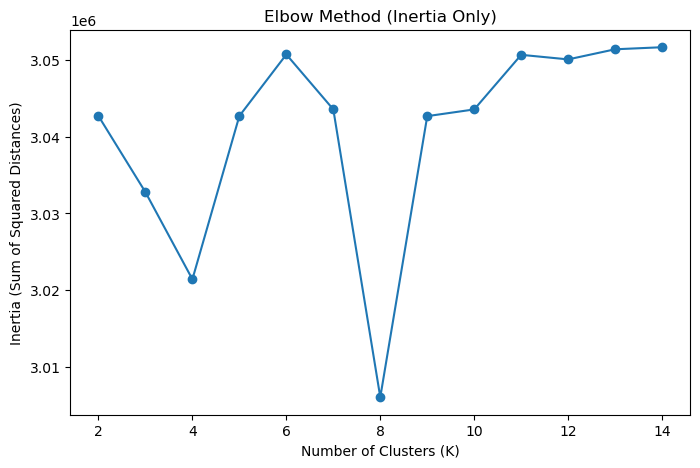

In [87]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method (Inertia Only)")
plt.show()

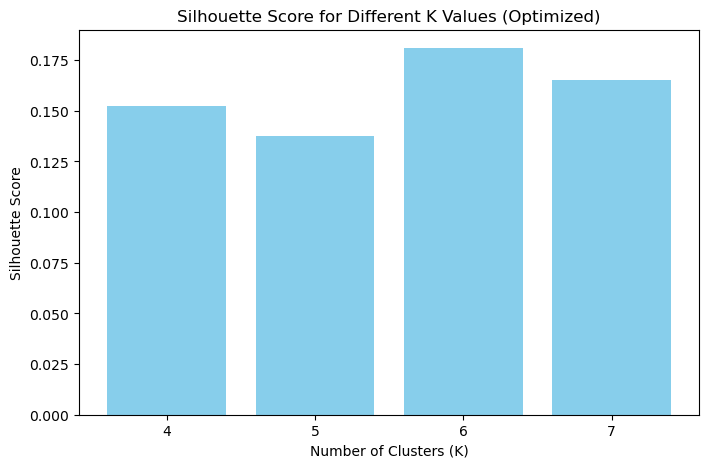

Optimized Silhouette Scores: {4: 0.1521139752201776, 5: 0.13739267998819732, 6: 0.18094703556077046, 7: 0.16496047179191764}


In [21]:
# Define the cluster range for evaluation
cluster_range = [4, 5, 6, 7]
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
sample_size = 10000
df_pd = df.compute()
if len(df_pd) > sample_size:
    tfidf_sample, df_sample = shuffle(tfidf_reduced, df_pd, random_state=42, n_samples=sample_size)
else:
    tfidf_sample, df_sample = tfidf_reduced, df_pd
silhouette_values = {}
for k in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
    labels = kmeans.fit_predict(tfidf_sample)
    silhouette_avg = silhouette_score(tfidf_sample, labels)
    silhouette_values[k] = silhouette_avg
plt.figure(figsize=(8, 5))
plt.bar(silhouette_values.keys(), silhouette_values.values(), color='skyblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values (Optimized)")
plt.xticks(list(silhouette_values.keys()))
plt.show()
print("Optimized Silhouette Scores:", silhouette_values)


Cluster 0 Top Words:
nice, faggot, work, fuck, get, man, go, call, like, good, make, job, sell, keep, thats, still, op, dude, dd, youre

Cluster 1 Top Words:
go, get, call, fuck, like, sell, put, buy, make, think, good, money, dont, stock, day, lol, well, one, time, shit

Cluster 2 Top Words:
earn, million, reinvesting, fuck, day, original, wow, dollar, end, keep, start, would, golden, goldenage, goldenbachsteinberg, 𡘅𡘆𡘇, goldenboi, goldenboy, goldenbut, goldenchrysus

Cluster 3 Top Words:
order, wheres, buy, robinhood, level, need, sell, look, though, youll, least, one, goldenage, goldembossed, goldemort, golden, 𡘅𡘆𡘇, goldenbachsteinberg, goldenboi, goldelectronics

Cluster 4 Top Words:
inflationary, dummy, economist, professor, unemployment, sky, pressure, accord, create, loan, fall, risk, low, probably, high, short, want, long, fuck, goldenboi

Cluster 5 Top Words:
poor, people, stop, youre, fuck, one, guy, still, less, dont, fag, try, lol, ban, rich, get, like, go, buy, man


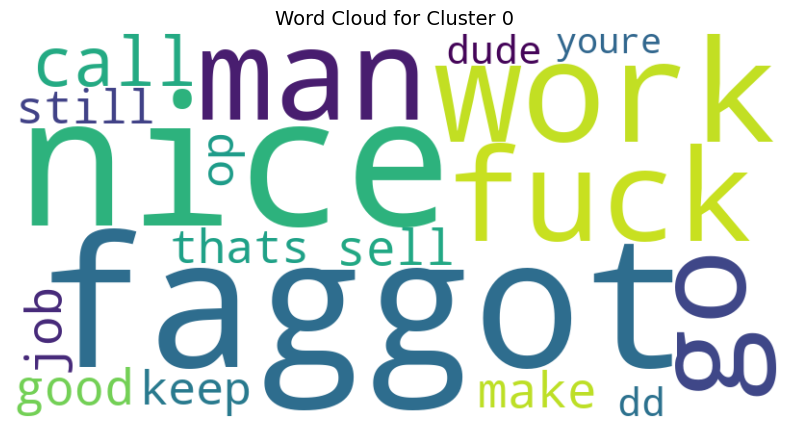

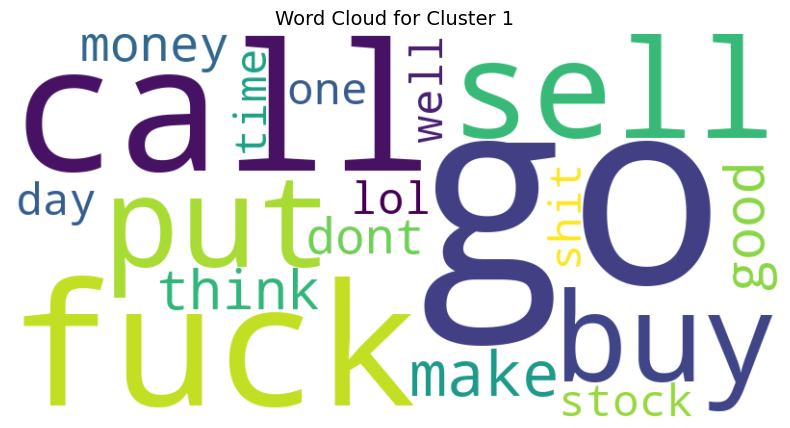

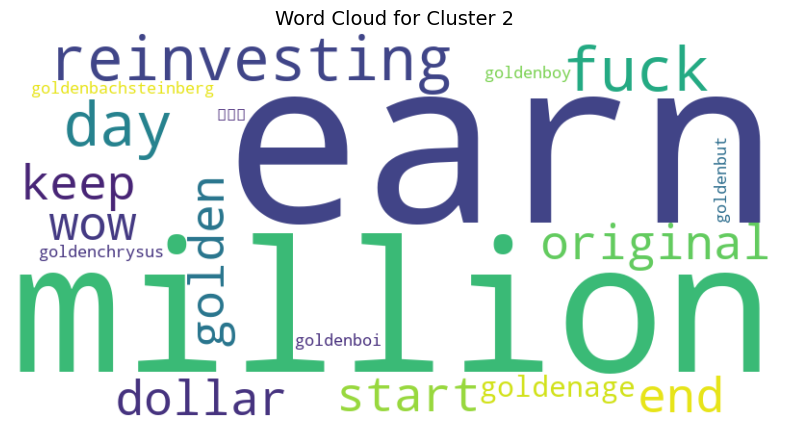

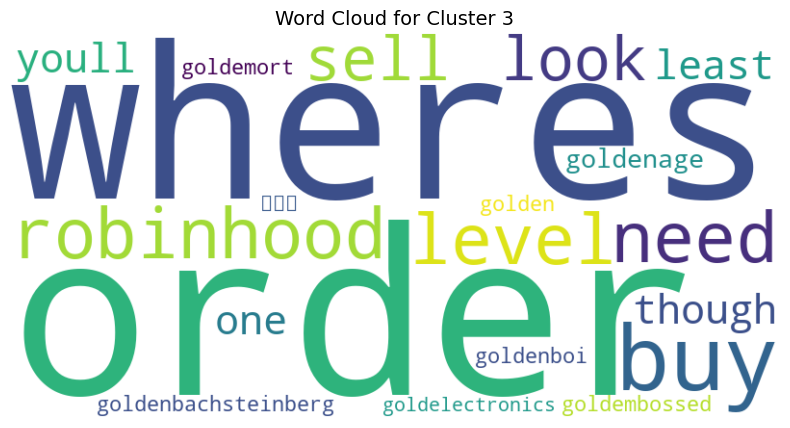

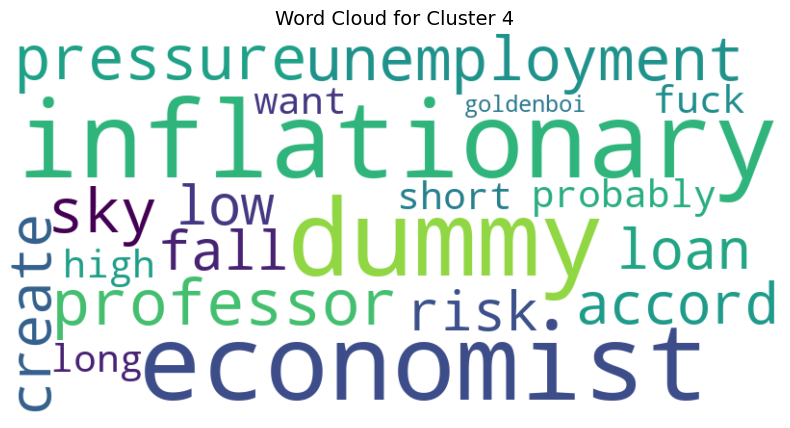

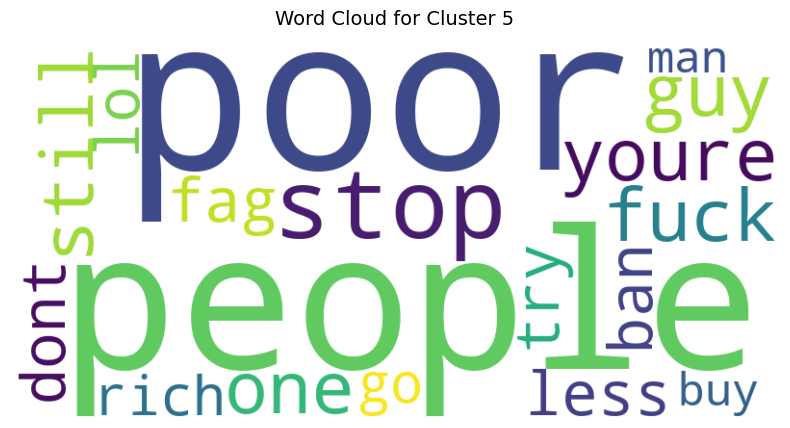

In [24]:
from wordcloud import WordCloud

best_k = 6
kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
df_pd["cluster"] = kmeans.fit_predict(tfidf_matrix)
feature_names = vectorizer.get_feature_names_out()
n_top_words = 20
cluster_top_words = {}
for cluster_id in range(best_k):
    cluster_indices = np.where(df_pd["cluster"] == cluster_id)[0]
    cluster_tfidf = tfidf_matrix[cluster_indices].sum(axis=0)
    cluster_tfidf_array = np.asarray(cluster_tfidf).flatten()
    top_indices = cluster_tfidf_array.argsort()[::-1][:n_top_words]
    top_terms = [feature_names[i] for i in top_indices]
    cluster_top_words[cluster_id] = top_terms
    print(f"\nCluster {cluster_id} Top Words:")
    print(", ".join(top_terms))
for cluster_id, words in cluster_top_words.items():
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud for Cluster {cluster_id}", fontsize=14)
    plt.axis("off")
    plt.show()

/software/python-anaconda-2022.05-el8-x86_64/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/software/python-anaconda-2022.05-el8-x86_64/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


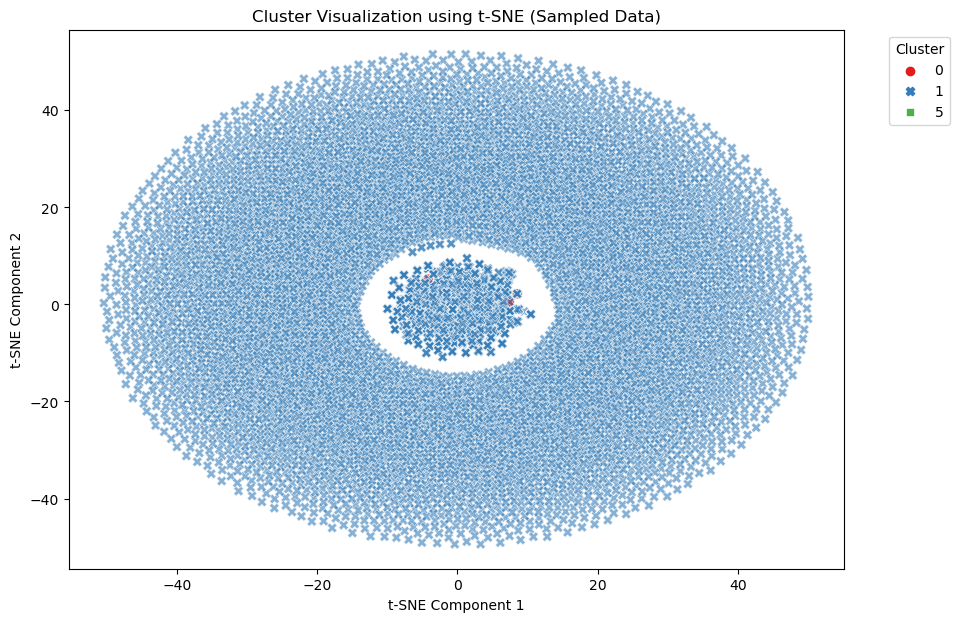

In [29]:
# Define the number of clusters based on your best K
best_k = 6  # Adjust based on your clustering analysis

# Reset DataFrame index to avoid duplicate index issues before sampling
df_pd = df_pd.reset_index(drop=True)

# Sample 10,000 points from the dataset
df_sampled = df_pd.sample(n=10000, random_state=42)

# Extract the TF-IDF features of the sampled data
tfidf_sampled = tfidf_matrix[df_sampled.index].toarray()

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=500)
tfidf_tsne = tsne.fit_transform(tfidf_sampled)

# Assign the reduced t-SNE components to the DataFrame
df_sampled["tsne_x"] = tfidf_tsne[:, 0]
df_sampled["tsne_y"] = tfidf_tsne[:, 1]

# Ensure cluster labels are present
df_sampled["cluster"] = df_pd.iloc[df_sampled.index]["cluster"]

# Plot t-SNE visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_sampled["tsne_x"],
    y=df_sampled["tsne_y"],
    hue=df_sampled["cluster"],
    palette="Set1",  # Different color palette for clarity
    style=df_sampled["cluster"],  # Different markers for better separation
    s=50,  # Size of points
    alpha=0.6  # Transparency for visibility
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Cluster Visualization using t-SNE (Sampled Data)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside
plt.show()
